In [5]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns
from pandas.api.types import CategoricalDtype
import itertools
from colour import Color
from datetime import date

In [6]:
today = date.today()
print("Today's date:", today)
date_today = str(today)
date_today

Today's date: 2021-11-26


'2021-11-26'

In [7]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path

WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor')

In [15]:
parents = [x for x in path.iterdir() if x.is_dir()]
parents


[WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-15_dualcolor_lowbindigtips'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-18_dualcolor_freshtaxol'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-22_dualcolor_freshtaxol'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-25_dualcolor_freshtaxol'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/mt-area')]

In [17]:
folders = []
for j in parents:
    folders0 = [x for x in j.iterdir() if x.is_dir()]
    folders0 = [i for i in folders0 if (str(i)[-3:] == 'yes') == True]
    folders =  folders + folders0

folders

[WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-18_dualcolor_freshtaxol/CH1_DCXGFP0.5nM_typeR303X_DCXRFP9.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-18_dualcolor_freshtaxol/CH2_DCXGFP0.5nM_typeR303X_DCXRFP8.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-18_dualcolor_freshtaxol/CH4_DCXGFP0.5nM_typeWT_DCXRFP8.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-22_dualcolor_freshtaxol/CH4_DCXGFP0.5nM_typeWT_DCXRFP6.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-22_dualcolor_freshtaxol/CH5_DCXGFP0.5nM_typeR303X_DCXRFP6.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-25_dualcolor_freshtaxol/CH1_DCXGFP0.5nM_typeWT_DCXRFP4.5nM-yes'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/

In [18]:
files = []
for j in range(0,len(folders)):  
    resultfolder = folders[j]/'results'
    files0 = [x for x in resultfolder.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('Results') != -1]
    files = files + files0
files 

[WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes/results/2_Results.csv'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes/results/3_Results.csv'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes/results/4_Results.csv'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes/results/5_Results.csv'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-17_dualcolor_wt_r303x/CH3_DCXGFP0.5nM_typeWT_DCXRFP9.5nM_freshtaxol-yes/results/6_Results.csv'),
 WindowsPath('C:/Users/Brouhard Lab/Dropbox/DCX/DualColor/2021-11-18_dualcolor_freshtaxol/CH1_DCXGFP0.5nM_typeR303X_DCXRFP9.5nM-yes/results/1_Results.csv'),
 WindowsPath('C:/Users/Brouh

In [27]:
ch = []
conc_DCXRFP = []
conc_DCXGFP = []
DCX_type = []
dates = []

for i in files:
    CHloc = str(i).find('CH')
    DCXRFPloc = str(i).rfind('RFP')
    DCXGFPloc = str(i).rfind('GFP')
    dcxtype = str(i).find('type')
    ch = ch + [str(i)[CHloc+2:CHloc+3]]
    conc_DCXRFP = conc_DCXRFP + [(str(i)[DCXRFPloc+3:DCXRFPloc+6])]
    conc_DCXGFP = conc_DCXGFP + [(str(i)[DCXGFPloc+3:DCXGFPloc+6])]
    DCX_type = DCX_type + [(str(i)[dcxtype+4:DCXRFPloc-4])]
    
    dateloc = str(i).find("202")
    dates = dates + [str(i)[dateloc : dateloc+10]]

    conc_DCXGFP =  [float(i) for i in conc_DCXGFP]
    conc_DCXRFP =  [float(i) for i in conc_DCXRFP]
    

In [67]:
dcxgfp_conc = '[GFP-DCX](nM)'
dcxrfp_conc = '[RFP-DCX](nM)'
corr_gfp = 'GFPxRFP Correlation %'
area_rfp = 'RFP Area %'
Type = 'Type'

In [68]:
metadf = pd.DataFrame({'Date': dates,'CH': ch,'Type': DCX_type,
                   dcxgfp_conc: conc_DCXGFP,
                   dcxrfp_conc: conc_DCXRFP})


In [69]:
df = pd.DataFrame(columns=['GFP','RFP','Cy5','GFPxRFP'])
for i in files:
    resultcsv = pd.read_csv(i, encoding='utf-8')
    arr = resultcsv['Mean'].values
    df = df.append(pd.DataFrame(arr.reshape(1,-1), columns=list(df)), ignore_index=True)



In [70]:
result = pd.concat([metadf, df], axis=1)

In [71]:
result[corr_gfp] = df['GFPxRFP'] / df['GFP'] * 100
result[area_rfp] = df['RFP'] / df['Cy5'] * 100


In [72]:
Type_order = ['WT','R303X']
category_Type = CategoricalDtype(Type_order, ordered=True,) #order mutants
result[Type] = result[Type].astype(category_Type)
result = result.sort_values(by=[Type, dcxrfp_conc])


In [73]:
result.to_csv(path/('correlation-analysis_'+date_today +'.csv'), encoding='utf-8', index=False)
result

,Date,CH,Type,[GFP-DCX](nM),[RFP-DCX](nM),GFP,RFP,Cy5,GFPxRFP,GFPxRFP Correlation %,RFP Area %
32,2021-11-25,3,WT,0.5,2.5,1.053,1.488,5.803,0.747,70.940171,25.641909
33,2021-11-25,3,WT,0.5,2.5,1.452,1.694,4.873,1.070,73.691460,34.762980
34,2021-11-25,3,WT,0.5,2.5,2.090,2.809,8.116,1.628,77.894737,34.610646
26,2021-11-25,1,WT,0.5,4.5,3.063,3.598,6.250,2.415,78.844270,57.568000
27,2021-11-25,1,WT,0.5,4.5,4.154,4.708,9.407,3.357,80.813674,50.047837
28,2021-11-25,1,WT,0.5,4.5,3.277,3.981,9.104,2.552,77.876106,43.728032
20,2021-11-22,4,WT,0.5,6.5,3.684,4.892,9.832,2.691,73.045603,49.755899
21,2021-11-22,4,WT,0.5,6.5,3.253,4.702,9.679,2.461,75.653243,48.579399
22,2021-11-22,4,WT,0.5,6.5,1.718,3.008,7.829,1.294,75.320140,38.421254
15,2021-11-18,4,WT,0.5,8.5,2.570,4.526,12.371,1.821,70.856031,36.585563


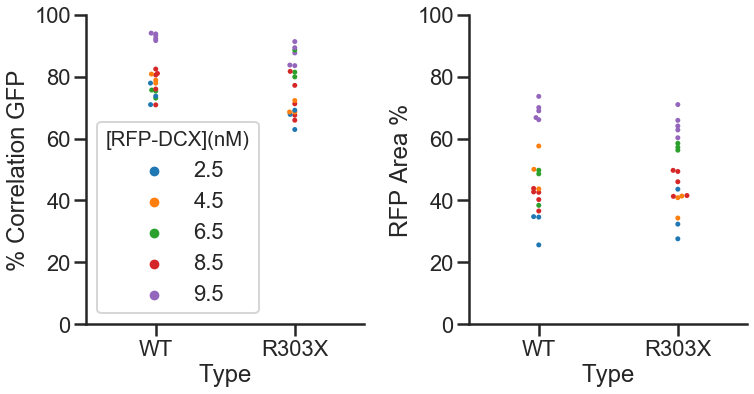

In [47]:
fig, axes = plt.subplots(1,2,figsize=(11,6))
sns.set_style("ticks")

corr = sns.swarmplot(ax=axes[0],x=Type, y=corr_gfp, hue=dcxrfp_conc, data=result)
area = sns.swarmplot(ax=axes[1],x=Type, y=area_rfp, hue=dcxrfp_conc, data=result)

corr.set(ylim=(0, 100))
area.set(ylim=(0, 100))

area.legend([],[], frameon=False)

sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()

plt.savefig(path/('correlation_area_'+date_today+'.pdf'))

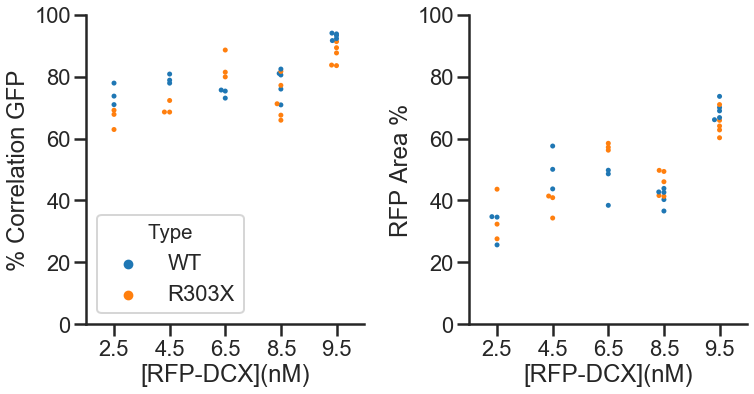

In [48]:
fig, axes = plt.subplots(1,2,figsize=(11,6))
sns.set_style("ticks")

corr = sns.swarmplot(ax=axes[0],x=dcxrfp_conc, y=corr_gfp, hue=Type, data=result)
area = sns.swarmplot(ax=axes[1],x=dcxrfp_conc, y=area_rfp, hue=Type, data=result)

corr.set(ylim=(0, 100))
area.set(ylim=(0, 100))

area.legend([],[], frameon=False)

sns.despine()
sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})
plt.tight_layout()

plt.savefig(path/('correlation_area_hueType'+date_today+'.pdf'))

In [ ]:
dcxgfp_conc = '[GFP-DCX](nM)'
dcxrfp_conc = '[RFP-DCX](nM)'
corr_gfp = 'GFPxRFP Correlation %'
area_rfp = 'RFP Area %'
Type = 'Type'

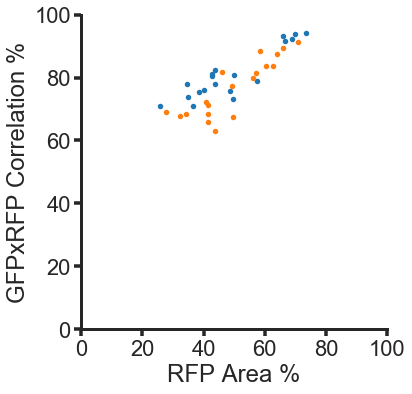

In [97]:
scattersize = 12
cap = 5

fig, ax = plt.subplots(1,1,figsize=(6.25,6))
#     plt.suptitle('Fitted pooled data', fontsize=30)

count = 0
for dcxtype in result[Type].unique(): #data[Type].unique()

    x = result[(result[Type]== dcxtype)][area_rfp]

    y = result[(result[Type]== dcxtype)][corr_gfp]

    ax.scatter(x , y,s= scattersize)
    count += 1

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)
ax.set_ylim(-0.015,100)
ax.set_xlim(-0.015,100)
ax.set_xlabel( area_rfp)
ax.xaxis.set_ticks(np.arange(0, 101, 20))

#ax.set_title('Rescue')
ax.set_ylabel(corr_gfp)


#ax.legend((Type_order),loc='upper left',title='DCX Type')
#fig.suptitle('[Tubulin] ' r'$= 6 \mu M$')
plt.tight_layout()
